<a href="https://colab.research.google.com/github/visithraravi98-lang/logical-regression/blob/main/logical_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

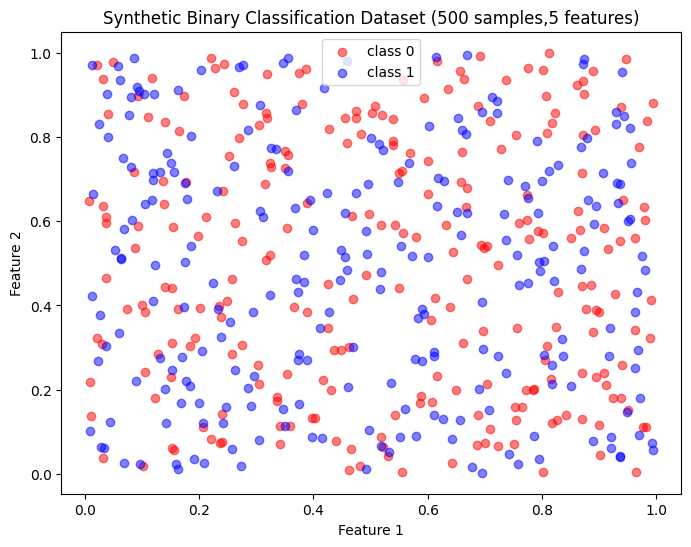

In [ ]:
# Generate synthetic binary classfication dataset
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
x=np.random.rand(500,5)
y=np.random.randint(0,2,500)
plt.figure(figsize=(8,6))
plt.scatter(x[y==0][:,0],x[y==0][:,1],color='red',label='class 0',alpha=0.5)
plt.scatter(x[y==1][:,0],x[y==1][:,1],color='blue',label='class 1',alpha=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Binary Classification Dataset (500 samples,5 features)')
plt.legend()
plt.show()

# New Section

Learned parameters (weights): [ 0.01270674 -0.08517742 -0.03971621  0.00408548 -0.05214794  0.05945199]


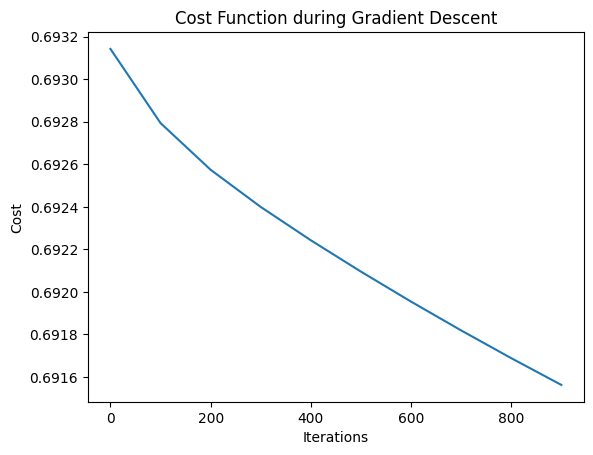

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

def compute_cost(x,y,theta):
    m=len(y)
    predictions=sigmoid(np.dot(x,theta))
    cost = -1*(1/m)*np.sum(y*np.log(predictions)+(1-y)*np.log(1-predictions))
    return cost

def gradient_descent(x,y,theta,learning_rate,iterations):
    m=len(y)
    cost_history=[]
    for i in range(iterations):
        predictions=sigmoid(np.dot(x,theta))
        gradient=(1/m)*np.dot(x.T,(predictions-y))
        theta-=learning_rate*gradient
        if i%100==0:
            cost_history.append(compute_cost(x,y,theta))
    return theta,cost_history

def predict(x,theta):
  probabilities=sigmoid(np.dot(x,theta))
  return [1 if prob>=0.5 else 0 for prob in probabilities]

def logistic_regression(x,y,learning_rate=0.01,iterations=1000):
  x=np.c_[np.ones((x.shape[0],1)),x]
  theta=np.zeros(x.shape[1])
  theta,cost_history=gradient_descent(x,y,theta,learning_rate,iterations)
  return theta,cost_history

theta,cost_history=logistic_regression(x,y,learning_rate=0.01,iterations=1000)
print("Learned parameters (weights):",theta)
plt.plot(range(0,len(cost_history)*100,100),cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title("Cost Function during Gradient Descent")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sklearn_model=LogisticRegression()
sklearn_model.fit(x,y)
sklearn_predictions=sklearn_model.predict(x)
sklearn_accuracy=accuracy_score(y,sklearn_predictions)
sklearn_precision=precision_score(y,sklearn_predictions)
sklearn_recall=recall_score(y,sklearn_predictions)
print("\nScikit-learn Logistic Regression:")
print(f"Accuracy:{sklearn_accuracy*100:.2f}%")
print(f"Precision:{sklearn_precision*100:.2f}%")
print(f"Recall:{sklearn_recall*100:.2f}%")


Scikit-learn Logistic Regression:
Accuracy:55.20%
Precision:55.14%
Recall:47.97%
